1. Try standard smac on x^2

In [44]:
from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario,BlackBoxFacade

# define evaluation function
def target_function(config: Configuration, seed: int = 67) -> float:
    x = config["x"]
    return x**2

# configure the configuration space
cs = ConfigurationSpace(seed = 67)
f = Float(name = "x", bounds = (-10,10))
cs.add(f)


# configure Scenario  
scenario = Scenario(
    name = "x_squared_basic",
    configspace = cs,
    deterministic = True,
    n_trials = 20,
    seed = 67
)

smac = BlackBoxFacade(
    scenario = scenario,
    target_function = target_function,
    #overwrite = True
)

incumbent = smac.optimize()
print("Best found configuration:", incumbent)

[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 8 to 5 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 5 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Best found configuration: Configuration(values={
  'x': -7.08859983e-05,
})


In [45]:
#general information about the smac optimization run 
print(smac.runhistory)
print("smac configspace:", smac.scenario.configspace)
print("finished runs/trials:", smac.runhistory.finished)
print("trials in runhistory:",len(smac.runhistory))
print(f"incumbent: x={incumbent['x']}, f(x)={smac.runhistory.average_cost(incumbent)}")

smac configspace: Configuration space object:
  Hyperparameters:
    x, Type: UniformFloat, Range: [-10.0, 10.0], Default: 0.0

finished runs/trials: 20
trials in runhistory: 20
incumbent: x=-7.08859983e-05, f(x)=5.024824754987602e-09


In [46]:
# get all configurations that were evaluated during the optimization run
rh = smac.runhistory
print(rh.get_configs())

[Configuration(values={
  'x': -4.3018858321011,
}), Configuration(values={
  'x': 0.1202480122447,
}), Configuration(values={
  'x': 8.8268729671836,
}), Configuration(values={
  'x': -5.4985159821808,
}), Configuration(values={
  'x': -9.8951227217913,
}), Configuration(values={
  'x': -1.1933827780372,
}), Configuration(values={
  'x': 1.9673000210974,
}), Configuration(values={
  'x': -0.2209531853373,
}), Configuration(values={
  'x': -0.0008976680138,
}), Configuration(values={
  'x': -2.7655522106686,
}), Configuration(values={
  'x': -0.000568122983,
}), Configuration(values={
  'x': -0.0002101078265,
}), Configuration(values={
  'x': 9.6355615422708,
}), Configuration(values={
  'x': 0.0002613233994,
}), Configuration(values={
  'x': -0.0002937959216,
}), Configuration(values={
  'x': 0.0004306934174,
}), Configuration(values={
  'x': 0.0002140043093,
}), Configuration(values={
  'x': 7.1302146554813,
}), Configuration(values={
  'x': 1.8295043567367,
}), Configuration(values=

In [47]:
# look at whole run history
for key, value in smac.runhistory.items():
    config =smac.runhistory.get_config(key.config_id)
    print("Configuration x value: ", config["x"])
    print("Origin: ", config.origin )
    print(key, value)


Configuration x value:  -4.3018858321011
Origin:  Initial Design: Sobol
TrialKey(config_id=1, instance=None, seed=196930371, budget=None) TrialValue(cost=18.506221712432176, time=0.0, cpu_time=0.0, status=<StatusType.SUCCESS: 1>, starttime=1780424964.4088082, endtime=1780424964.4098108, additional_info={})
Configuration x value:  0.1202480122447
Origin:  Initial Design: Sobol
TrialKey(config_id=2, instance=None, seed=196930371, budget=None) TrialValue(cost=0.014459584448801521, time=0.0, cpu_time=0.0, status=<StatusType.SUCCESS: 1>, starttime=1780424964.4158094, endtime=1780424964.4168086, additional_info={})
Configuration x value:  8.8268729671836
Origin:  Initial Design: Sobol
TrialKey(config_id=3, instance=None, seed=196930371, budget=None) TrialValue(cost=77.91368637879663, time=0.0, cpu_time=0.0, status=<StatusType.SUCCESS: 1>, starttime=1780424964.4248137, endtime=1780424964.4258122, additional_info={})
Configuration x value:  -5.4985159821808
Origin:  Initial Design: Sobol
Trial

In [48]:
# all configs with values
for trial_info, trial_value in smac.runhistory.items():
    print("x: ", smac.runhistory.get_config(trial_info.config_id)["x"], "with cost: ", trial_value.cost)



x:  -4.3018858321011 with cost:  18.506221712432176
x:  0.1202480122447 with cost:  0.014459584448801521
x:  8.8268729671836 with cost:  77.91368637879663
x:  -5.4985159821808 with cost:  30.233678006297687
x:  -9.8951227217913 with cost:  97.91345367931045
x:  -1.1933827780372 with cost:  1.4241624549157847
x:  1.9673000210974 with cost:  3.870269373009831
x:  -0.2209531853373 with cost:  0.04882031011069924
x:  -0.0008976680138 with cost:  8.05807862999637e-07
x:  -2.7655522106686 with cost:  7.64827902993398
x:  -0.000568122983 with cost:  3.227637238128183e-07
x:  -0.0002101078265 with cost:  4.41452987565541e-08
x:  9.6355615422708 with cost:  92.84404623488804
x:  0.0002613233994 with cost:  6.828991907397191e-08
x:  -0.0002937959216 with cost:  8.631604354879335e-08
x:  0.0004306934174 with cost:  1.854968197916906e-07
x:  0.0002140043093 with cost:  4.579784439897007e-08
x:  7.1302146554813 with cost:  50.839961033240314
x:  1.8295043567367 with cost:  3.3470861913185663
x:  -7

In [49]:
# print all hyperparameters in config space
for i in smac.scenario.configspace.values():    
    print("smac hyperparameters:", i)

# print all names + hyperparameters
for name, hp in smac.scenario.configspace.items():    
    print(name)
    print(hp)

smac hyperparameters: x, Type: UniformFloat, Range: [-10.0, 10.0], Default: 0.0
x
x, Type: UniformFloat, Range: [-10.0, 10.0], Default: 0.0


In [50]:
# get upper and lower bounds of hyperparameters
for hp in smac.scenario.configspace.values():
    print(f"Upper Bound: {hp.upper}, Lower Bound: {hp.lower}")

Upper Bound: 10.0, Lower Bound: -10.0


2. Visualization

Text(0, 0.5, 'Count')

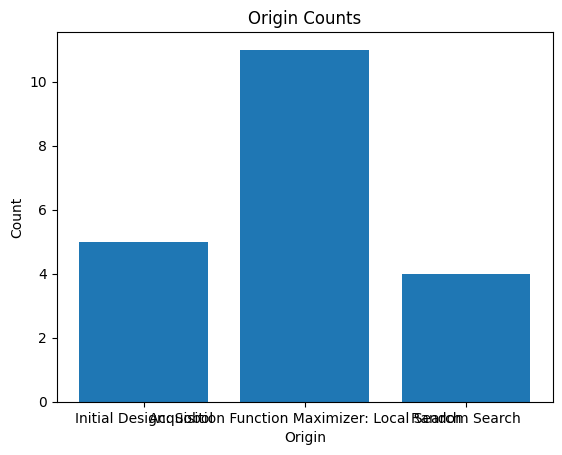

In [58]:
from collections import Counter
from matplotlib import pyplot as plt

origins = []

for config in smac.runhistory.get_configs():
    origins.append(config.origin)

origin_counts = Counter(origins)
fig, ax = plt.subplots()
ax.bar(origin_counts.keys(), origin_counts.values())
ax.set_title("Origin Counts")
ax.set_xlabel("Origin")
ax.set_ylabel("Count")  

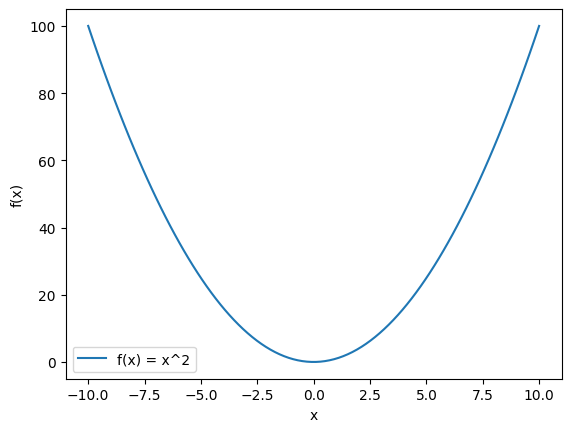

In [51]:
# draw simple x2 

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
hp = next(iter(smac.scenario.configspace.values()))
name = hp.name
lower = hp.lower
upper = hp.upper

x = np.linspace(lower, upper, 100)
y = x**2

ax.plot(x, y, label='f(x) = x^2')
ax.set_xlabel(name)
ax.set_ylabel(f'f({name})')
ax.legend()

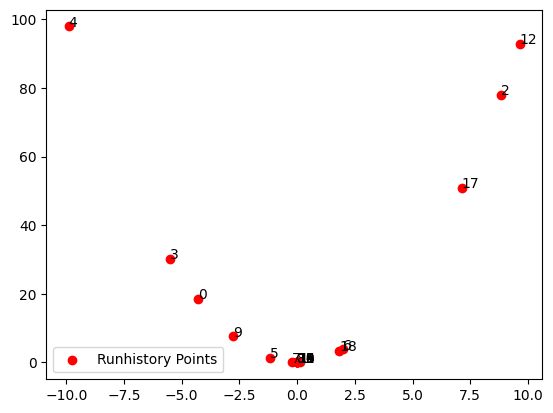

In [52]:
#draw the runhistory points
x = []
y = []

for trial_info, trial_value in smac.runhistory.items():
    x.append(smac.runhistory.get_config(trial_info.config_id)["x"])
    y.append(trial_value.cost)

fig, ax = plt.subplots()
ax.scatter(x, y, color='red', label='Runhistory Points')

for i in range(len(x)):
    ax.annotate(str(i), (x[i], y[i]))
ax.legend()

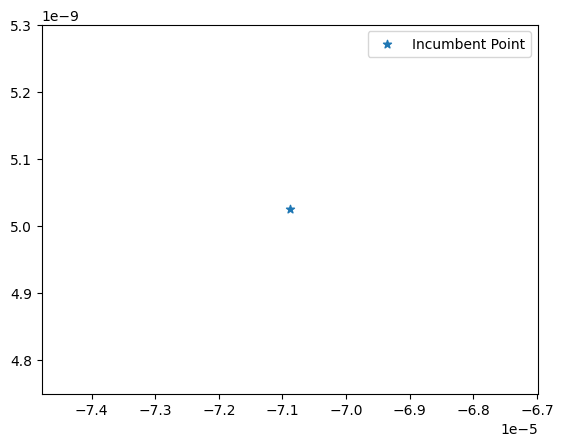

In [53]:
# draw the incumbent point
incumbent_x = incumbent['x']
incumbent_y = smac.runhistory.get_cost(incumbent)
fig, ax = plt.subplots()
ax.scatter(incumbent_x, incumbent_y, marker = "*", label='Incumbent Point')
ax.legend()

3. Advanced Visualizations

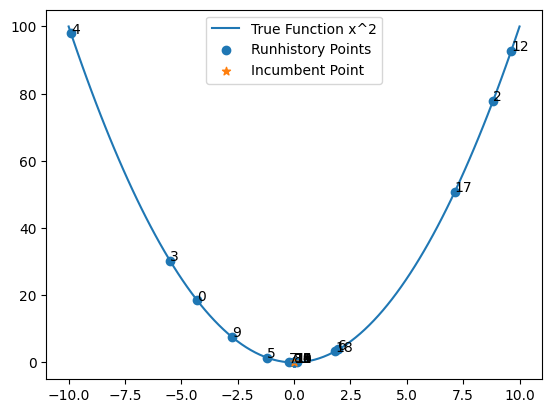

In [54]:
# everything together x2 + runhistory + incumbent
fig, ax = plt.subplots()
hp = smac.scenario.configspace["x"]
x_true = np.linspace(hp.lower, hp.upper, 100)
y_true = x_true**2
ax.plot(x_true, y_true, label='True Function x^2')

x_history = []
y_history = []

for trial_info, trial_value in smac.runhistory.items():
    x_history.append(smac.runhistory.get_config(trial_info.config_id)["x"])
    y_history.append(trial_value.cost)

ax.scatter(x_history, y_history,label='Runhistory Points')

for i in range(len(smac.runhistory)):
    ax.annotate(str(i), (x_history[i], y_history[i]))

incumbent_x = incumbent['x']
incumbent_y = smac.runhistory.get_cost(incumbent)

ax.scatter(incumbent_x, incumbent_y, marker = "*", label='Incumbent Point')
ax.legend()


Text(0, 0.5, 'Configuration Value')

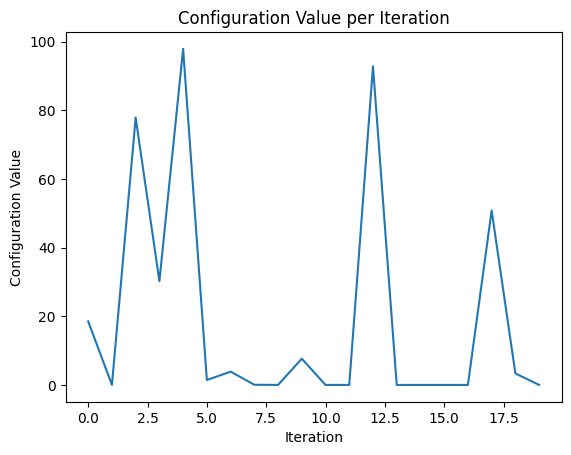

In [55]:
# configuration value per iteration

fig,ax = plt.subplots()
x = range(len(smac.runhistory))
y = [trial_value.cost for trial_info, trial_value in smac.runhistory.items()]
ax.plot(x,y)
ax.set_title("Configuration Value per Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Configuration Value")

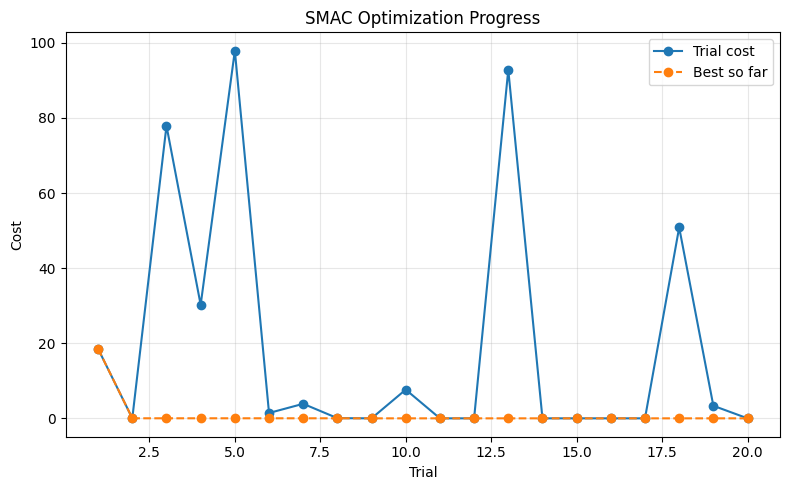

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Sort trials by evaluation order
trials = sorted(
    smac.runhistory.items(),
    key=lambda item: item[1].starttime,
)

# Extract costs
costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)

# Iteration numbers: 1, 2, 3, ...
iterations = np.arange(1, len(costs) + 1)

# Best-so-far curve
best_so_far = np.minimum.accumulate(costs)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations, costs, marker="o", linestyle="-", label="Trial cost")
ax.plot(iterations, best_so_far, marker="o", linestyle="--", label="Best so far")

ax.set_title("SMAC Optimization Progress")
ax.set_xlabel("Trial")
ax.set_ylabel("Cost")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

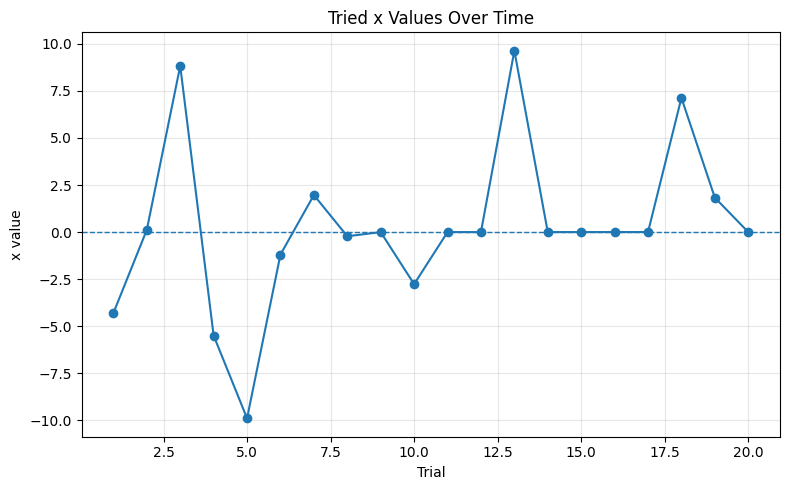

In [57]:
# Extract x values
x_values = np.array([
    smac.runhistory.get_config(trial_key.config_id)["x"]
    for trial_key, _ in trials
], dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations, x_values, marker="o", linestyle="-")

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Tried x Values Over Time")
ax.set_xlabel("Trial")
ax.set_ylabel("x value")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()